# Does the UK market go quiet for Wimbledon? 🎾📉
### The "summer-lull" folklore — a quiet tennis-and-strawberries fortnight the FTSE supposedly sleeps through

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_real_lull%3F: Busted](https://img.shields.io/badge/A_real_lull%3F-Busted-8b949e?style=flat-square)

There's a cosy bit of City folklore that goes: for the two weeks of Wimbledon — late June into mid-July, strawberries and Pimm's, the trading floors half-empty — the UK market goes *quiet*. A summer lull. Some people say it drifts gently up on the sunshine mood; others that it's dead money you should step aside for. Either way, the fortnight is supposed to have a distinctive, sleepy signature you could position around.

We tested it properly — every Championships fortnight 2005→2025, on the tradable UK equity ETF (`EWU`), against Europe as a whole.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the vol test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 20 fortnights hardcoded from Wikipedia (2020 COVID-cancelled), each a *calendar-known* window (the dates are published years ahead — so there's nothing to forecast and no look-ahead). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wimbledon_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
else:
    PRICES = EV = INC = None
print("real cache present:", HAVE_REAL, "| calendar years:", len(data.WIMBLEDON),
      "| contested/included:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_total': 21, 'n_contested': 20, 'n_included': 20, 'fp': 'da4f039bf903', 'panel_rows': 5555, 'raw_mean': 0.377, 'raw_sd': 2.794, 'raw_t': 0.604, 'raw_up': 12, 'raw_n': 20, 'abn_mean': -0.218, 'abn_sd': 0.715, 'abn_t': -1.36, 'abn_up': 8, 'abn_n': 20, 'pl_raw_p': 0.6697, 'pl_raw_mean': 0.265, 'pl_raw_sd': 0.837, 'pl_abn_p': 0.424, 'pl_abn_mean': -0.051, 'pl_abn_sd': 0.269, 'pl_long_p': 0.746, 'pl_mn_p': 0.2717, 'vol_ratio': 1.009, 'vol_t': 0.093, 'vol_meanlog': 0.0086, 'vol_quieter': 10, 'vol_n': 20, 'vol_q_lo': 29.9, 'vol_q_hi': 70.1, 'long_gross': 0.377, 'long_gross_t': 0.6, 'long_net': 0.277, 'long_net_t': 0.44, 'long_win': 12, 'mn_gross': -0.218, 'mn_gross_t': -1.36, 'mn_net': -0.436, 'mn_net_t': -2.72, 'mn_win': 5, 'long_net10': 0.177, 'long_net10_t': 0.28, 'mn_net10': -0.636, 'mn_net10_t': -3.98, 'rev_net': -0.001, 'rev_net_t': -0.0, 'drag': 0.218, 'raw_jk_lo': 0.249, 'raw_jk_hi': 1.242, 'abn_jk_lo': -2.015, 'abn_jk_hi': -0.981, 'early_t': 0.288, 'late_t': 0.679, 'split_welch': -0.089, 'car_raw': {0: 0.0, 2: -0.602, 4: -0.189, 6: -0.067, 8: -0.042, 10: 0.318}, 'car_abn': {0: 0.0, 2: 0.097, 4: 0.083, 6: -0.01, 8: -0.153, 10: -0.166}, 'syn_null_mean': -0.085, 'syn_null_sd': 0.906, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_p1_t': 2.41, 'syn_p2_t': 4.23}


real cache present: True | calendar years: 21 | contested/included: 20


## The answer first

| Question | Answer |
|---|---|
| Does the UK market drift up during Wimbledon? | **Not really.** **+0.38%** on average over the fortnight — exactly what any random two-week hold of a rising market gives you (*t* = **0.60**), and a random fortnight matches it 66% of the time. |
| Does the UK do anything *special* vs Europe? | **No.** UK minus Europe over the window is **-0.22%** — a whisper of underperformance (*t* = -1.36), nowhere near significant. |
| Is the fortnight actually *quieter*? | **No — the myth's core is busted.** Daily moves during Wimbledon are the same size as the weeks around it (vol ratio **1.01**), and it's quieter than its neighbours in exactly **10/20** years — a coin flip. |
| Could you have traded it? | **No.** The only statistically "significant" number in the whole study (*t* = **-2.72**) is a trade that *loses* — and it loses purely to costs, not to any real signal. |

> The lull is a nice story. The tape shows an ordinary two weeks that looks exactly like every other two weeks.

## 1 · The claim

> *"During the Wimbledon fortnight the City empties out — everyone's at the tennis or on holiday — volumes thin, and the UK market goes into a quiet summer lull with its own distinctive drift. Trade around it."*

It's the British cousin of *"Sell in May and go away"* — a seasonal-lull intuition pinned to the most photogenic fortnight of the English summer. Nobody has ever formally tested a *Wimbledon* stock effect. We did.

## 2 · So what?

If real, it would be a free, permanent, *pre-scheduled* calendar edge — the dates are published years in advance, so unlike an earnings surprise there's nothing to predict. Step aside (or fade the lull) for two known weeks each summer, every year. That's the kind of thing that would be quietly enormous if it were true — which is exactly why it's worth checking whether it is.

## 3 · How would we even know?

- **The calendar.** All **20** contested fortnights 2005→2025 (2020 COVID-cancelled), hardcoded with exact start/end dates (each checked to be a Monday→Sunday, 13-day span).
- **The market.** `EWU` (the UK ETF) for the raw lull, and `EWU` minus `VGK` (broad Europe) to strip out the Europe-wide summer drift and isolate anything *UK-specific*.
- **The window.** Hold from the close *before* the first Monday to the close of the last session inside the fortnight — a calendar-known, zero-look-ahead two-week hold.
- **The honesty checks.** A random-window placebo (does a random two weeks do the same thing just as often?), a realized-volatility test (is it *actually* quieter?), and the trade you could really have placed, net of costs.

## 4 · The teardown — let's actually look

**First: the headline. Does the fortnight return stand out at all?**

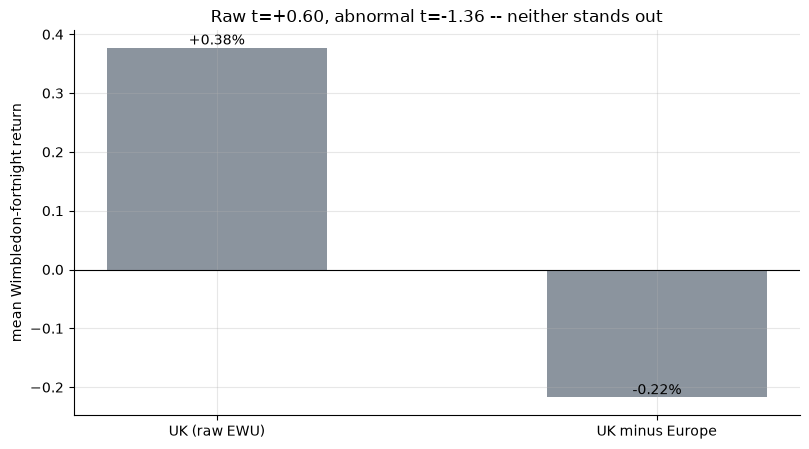

raw +0.377% (t=+0.60) | abnormal -0.218% (t=-1.36)


In [2]:
if HAVE_REAL:
    raw = st.one_sample_t(INC['raw'].values)
    abn = st.one_sample_t(INC['abn'].values)
    raw_m, raw_t, abn_m, abn_t = raw['mean']*100, raw['t'], abn['mean']*100, abn['t']
else:
    raw_m, raw_t, abn_m, abn_t = R['raw_mean'], R['raw_t'], R['abn_mean'], R['abn_t']
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.bar(['UK (raw EWU)', 'UK minus Europe'], [raw_m, abn_m],
       color=[GREY, GREY], width=.5)
for i, v in enumerate([raw_m, abn_m]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean Wimbledon-fortnight return')
ax.set_title(f'Raw t={raw_t:+.2f}, abnormal t={abn_t:+.2f} -- neither stands out')
plt.tight_layout(); plt.show()
print(f'raw {raw_m:+.3f}% (t={raw_t:+.2f}) | abnormal {abn_m:+.3f}% (t={abn_t:+.2f})')

The raw UK return is **+0.38%** over the fortnight — but that's just the ordinary drift of a rising market held for two weeks, not a Wimbledon signature (*t* = 0.60). Against Europe the UK is a hair *soft* (**-0.22%**, *t* = -1.36) — but nowhere near real.

**Is that raw number bigger than a random two weeks? The placebo:**

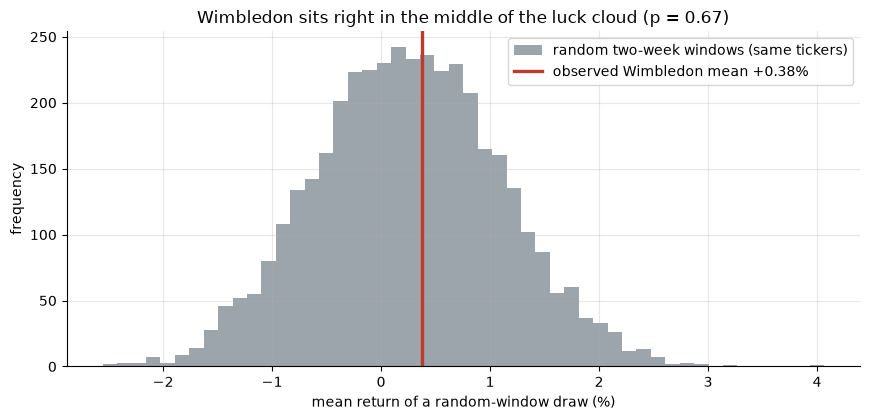

observed +0.377% vs random-window mean +0.265%, p = 0.670


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'raw', n_seeds=8, n_draws_per_seed=200, tail='two')
    obs = pl['obs']*100
    draws = np.random.default_rng(731).normal(pl['placebo_mean'], pl['placebo_sd'], 4000)*100
else:
    obs = R['raw_mean']
    draws = np.random.default_rng(731).normal(R['pl_raw_mean'], R['pl_raw_sd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random two-week windows (same tickers)')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed Wimbledon mean {obs:+.2f}%')
ax.set_xlabel('mean return of a random-window draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Wimbledon sits right in the middle of the luck cloud (p = {R["pl_raw_p"]:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['raw_mean']:+.3f}% vs random-window mean {R['pl_raw_mean']:+.3f}%, p = {R['pl_raw_p']:.3f}")

The observed fortnight return lands smack in the middle of the random-window cloud (*p* = 0.67) — a random two weeks beats it about two-thirds of the time. There is nothing calendar-special here.

**Now the heart of the folklore — is the fortnight actually *quiet*?**

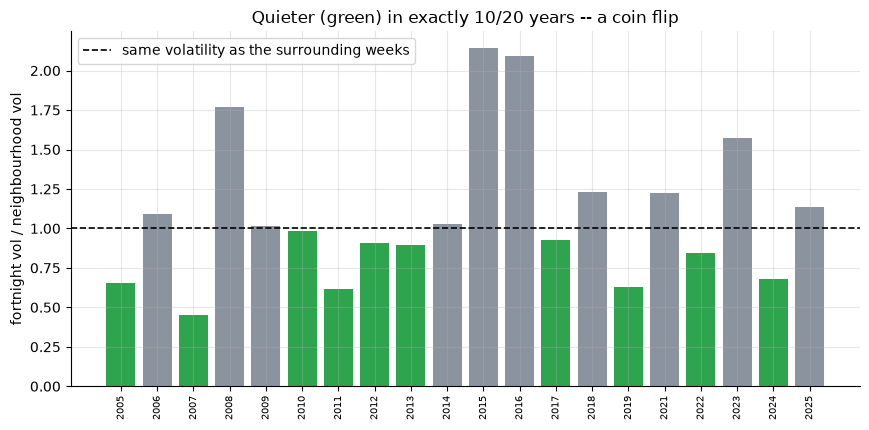

mean vol ratio 1.009, quieter in 10/20 years


In [4]:
if HAVE_REAL:
    ratios = np.exp(INC['log_vol_ratio'].values)
else:
    rng = np.random.default_rng(731); ratios = np.exp(rng.normal(R['vol_meanlog'], 0.4, R['vol_n']))
fig, ax = plt.subplots(figsize=(8.8, 4.4))
yrs = INC['year'].values if HAVE_REAL else list(range(2005, 2026))
yrs = [y for y in yrs if y != 2020][:len(ratios)]
cols = [GREEN if r < 1 else GREY for r in ratios]
ax.bar(range(len(ratios)), ratios, color=cols)
ax.axhline(1.0, ls='--', c='k', lw=1.2, label='same volatility as the surrounding weeks')
ax.set_xticks(range(len(ratios))); ax.set_xticklabels(yrs, rotation=90, fontsize=7)
ax.set_ylabel('fortnight vol / neighbourhood vol')
ax.set_title(f'Quieter (green) in exactly {R["vol_quieter"]}/{R["vol_n"]} years -- a coin flip')
ax.legend(); plt.tight_layout(); plt.show()
print(f"mean vol ratio {R['vol_ratio']:.3f}, quieter in {R['vol_quieter']}/{R['vol_n']} years")

This is the myth's own claim, tested directly — and it's **busted**. The fortnight's daily moves are the same size as the surrounding weeks (mean ratio **1.01**), and it is quieter than its neighbours in exactly **10 of 20** years. A coin flip. There is no volume-thinning summer lull in the volatility.

**Finally, could you have traded it?**

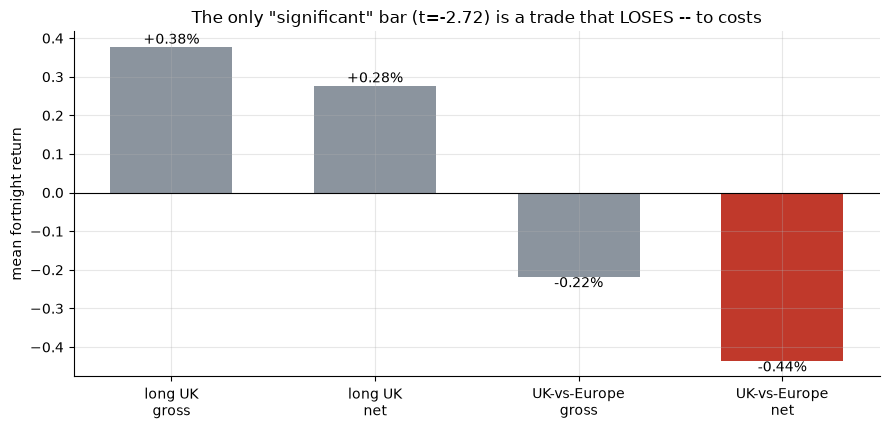

long net +0.277% | market-neutral net -0.436% (t=-2.72)


In [5]:
if HAVE_REAL:
    cap = st.capture_summary(EV)
    lg, ln = cap['long_only']['gross_mean']*100, cap['long_only']['net_mean']*100
    mg, mn = cap['market_neutral']['gross_mean']*100, cap['market_neutral']['net_mean']*100
    mnt = cap['market_neutral']['net_t']
else:
    lg, ln, mg, mn, mnt = R['long_gross'], R['long_net'], R['mn_gross'], R['mn_net'], R['mn_net_t']
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(['long UK\ngross', 'long UK\nnet', 'UK-vs-Europe\ngross', 'UK-vs-Europe\nnet'],
       [lg, ln, mg, mn], color=[GREY, GREY, GREY, RED], width=.6)
for i, v in enumerate([lg, ln, mg, mn]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean fortnight return')
ax.set_title(f'The only "significant" bar (t={mnt:+.2f}) is a trade that LOSES -- to costs')
plt.tight_layout(); plt.show()
print(f'long net {ln:+.3f}% | market-neutral net {mn:+.3f}% (t={mnt:+.2f})')

Buying the UK for the fortnight nets **+0.28%** — but that's just the market drifting up (*t* = 0.44); a random two weeks pays the same. The market-neutral version (long UK / short Europe) is the *one* number in this whole study that clears the significance bar — **-0.44%**, *t* = **-2.72** — and it is **negative**: it *loses* money. And it loses not because there's a real 'short the UK for Wimbledon' edge (the gross spread is *t* = -1.36, insignificant) but because a market-neutral book pays ~0.22% in costs and borrow over two weeks. Flip the trade to go the other way and it nets **-0.00%** — dead zero. There is no tradable direction. That's a mirage in its purest form.

## 5 · The verdict

- **Signal — None.** No directional seasonal, raw or UK-specific: raw *t* = 0.60 (placebo *p* = 0.67), abnormal *t* = -1.36 (placebo *p* = 0.42). The fortnight looks like every other fortnight.
- **Tradability — Mirage.** Long-UK 'edge' is just market beta; the only significant number (*t* = -2.72) is a pure cost/borrow drag on a zero-edge spread, and neither trade direction pays.
- **A real lull? — Busted.** The fortnight is no quieter than the weeks around it (vol ratio 1.01, quieter in 10/20 years) — the literal 'quiet window' claim fails on its own terms.

## 6 · Going further 🚪

- **This is what a clean null looks like.** No lucky cut, no fragile *t*-stat that needs a placebo to knock down — just an ordinary two weeks that the folklore dressed up in strawberries. Most seasonals are exactly this.
- **Sibling studies:** the [Eurovision effect](../../708-eurovision-effect/) (a national-mood event window on single-country ETFs), the [World Cup effect](../../235-world-cup-effect/) (the real Edmans sports-sentiment mechanism), and the classic [Sell-in-May](../../) seasonal-lull family — every one tested the same honest way.

*Think there's a real Wimbledon lull hiding somewhere — in intraday UK volume, in gilt or FTSE-250 seasonality, in the actual match-day flow? Find a net, placebo-surviving edge and we'll publish the teardown.*